# Predictive Data Modeling 
##### notebook code (C) 2022-2026 Timothy James Becker
## CH3: Linear Regression Overview

Linear Regression is a simple supervised method for fitting a linear model to a pair of column vectors.  More specfically we are assuming that their is a linear relationship between columns vectors $X$ and $Y$ from dataset $D$ where there are $n$ observations (row vectors).  This linear model geometrically describes a line object that generally slices through the 2D space made by ploting $X$ against $Y$ for each observation.

$
D = \begin{pmatrix}
10 && 1 && 4 \\
8 && 2 && 6 \\
11 && 3 && 2 \\
15 && 1 && 2 \\
11 && 3 && 4 \\
10 && 3 && 1 \\
12 && 2 && 5 
\end{pmatrix} \Rightarrow \;\;\;\;
X = D_1 =
\begin{pmatrix}
10 \\
8 \\
11 \\
15 \\
11 \\
10 \\
12 
\end{pmatrix},\;\;\;
Y = D_2 = 
\begin{pmatrix}
1 \\
2 \\
3 \\
1 \\
3 \\
3 \\
2  
\end{pmatrix},\;\;\;
Z = D_3 =
\begin{pmatrix}
4 \\
6 \\
2 \\
2 \\
4 \\
1 \\
5 
\end{pmatrix}
$


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.spatial import ConvexHull
import statsmodels.api as sm
from matplotlib import pyplot as plt

In [3]:
D    = np.asarray([[10,8,11,15,11,10,12],[1,2,3,1,3,3,2],[4,6,2,2,4,1,5]],dtype=np.int32)
cols = ['X','Y','Z']
D    = pd.DataFrame(D.T,columns=cols)
D

,X,Y,Z
0,10,1,4
1,8,2,6
2,11,3,2
3,15,1,2
4,11,3,4
5,10,3,1
6,12,2,5


In [6]:
import random

def model(x, b_0, b_1):
    return b_0 + b_1 * x
b

def get_ext(y, x):
    ymin = y.min()
    ymax = y.max()
    xmin = x.min()
    xmax = x.max()
    return [ymin, ymax, xmin, xmax]


def slope_intercept(p1, p2):
    if p2[0] - p1[0] == 0:
        return 99999
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    return m


def get_rand_pts(x: list, y: list):
    i = random.randrange(0, len(x))
    j = random.randrange(0, len(x))
    while (i == j):
        i = random.randrange(0, len(x))
        j = random.randrange(0, len(x))
    return x[i], y[i], x[j], y[j]


def loss(y: list, yhat: list, a=2, mean=False):
    return sum((i - j) ** a for i, j in zip(y, yhat))


x_values = D[:]['X']
y_values = D[:]['Y']
ymin, ymax, xmin, xmax = get_ext(y_values, x_values)

x_values = list(x_values)
y_values = list(y_values)

# --- ADD ONTO YOUR EXISTING CODE BELOW THIS LINE ---

def intercept_from_point(x0, y0, m):
    return y0 - m * x0

best_loss = float("inf")
best_b0 = None
best_b1 = None

N = 1000
alpha = 2   # this matches your loss() default

for _ in range(N):
    # 1) pick two random points
    x1, y1, x2, y2 = get_rand_pts(x_values, y_values)

    # 2) slope from the two points
    m = slope_intercept((x1, y1), (x2, y2))
    if m == 99999:   # skip vertical-line case
        continue

    # 3) intercept from one of the points
    b0 = intercept_from_point(x1, y1, m)
    b1 = m

    # 4) predict yhat for all x and compute loss
    yhat = [model(xi, b0, b1) for xi in x_values]
    L = loss(y_values, yhat, a=alpha)

    # 5/6) keep best (min loss)
    if L < best_loss:
        best_loss, best_b0, best_b1 = L, b0, b1

print(f"Best of {N} random lines (alpha={alpha}):")
print("min_loss =", best_loss)
print("beta0    =", best_b0)
print("beta1    =", best_b1)

Best of 1000 random lines (alpha=2):
min_loss = 5.0
beta0    = 2.0
beta1    = 0.0


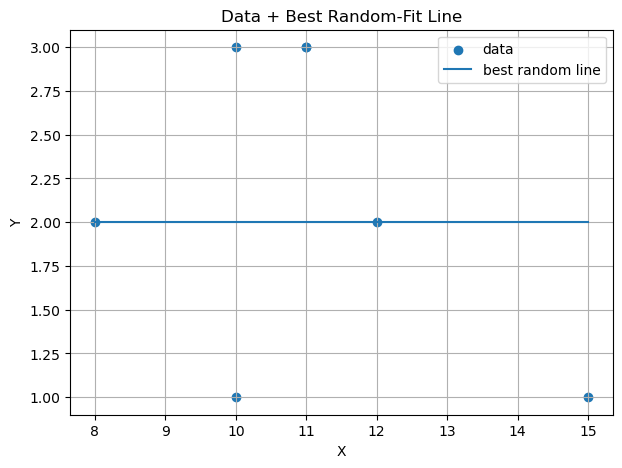

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# scatter the original data
plt.figure(figsize=(7,5))
plt.scatter(x_values, y_values, label="data")

# line using your best betas
x_line = np.linspace(min(x_values), max(x_values), 200)
y_line = best_b0 + best_b1 * x_line
plt.plot(x_line, y_line, label="best random line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Data + Best Random-Fit Line")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import numpy as np
import pandas as pd
import random

# Create the DataFrame D (columns: X, Y, Z)
data = np.array([
    [10, 8, 11, 15, 11, 10, 12],  # X
    [ 1, 2,  3,  1,  3,  3,  2],  # Y
    [ 4, 6,  2,  2,  4,  1,  5],  # Z
], dtype=np.int32)

D = pd.DataFrame(data.T, columns=["X", "Y", "Z"])

# Define the number of iterations and alpha
n_iterations = 1000
alpha = 2

# Initialize variables to store the best betas and loss
best_b0, best_b1 = None, None
best_loss = float("inf")

# Perform the iterations
for _ in range(n_iterations):
    # Select two random data points (different indices)
    index1, index2 = random.sample(range(len(D)), 2)

    x1, y1 = D["X"].iloc[index1], D["Y"].iloc[index1]
    x2, y2 = D["X"].iloc[index2], D["Y"].iloc[index2]

    if x1 != x2:
        # Compute b1 (slope) and b0 (intercept)
        b1 = (y2 - y1) / (x2 - x1)
        b0 = y1 - b1 * x1

        # Predict y_hat for all X values
        y_hat = b0 + b1 * D["X"]

        # Compute the loss L = sum(|y - y_hat|^alpha)
        L = np.sum(np.abs(D["Y"] - y_hat) ** alpha)

        # Update the best betas and loss if the current loss is smaller
        if L < best_loss:
            best_loss = L
            best_b0, best_b1 = b0, b1

# Print the best loss and betas
print(f"Best Loss: {best_loss}")
print(f"Best b0: {best_b0}, Best b1: {best_b1}")

Best Loss: 5.0
Best b0: 2.0, Best b1: -0.0


We can first use what we learned in CH2:Statistical Suplements to see how $X$ and $Y$ connect by correlation (-1 or 1 are very correlated while 0 is random):

#### $r_{xy} = \displaystyle\frac{\sum_{i=1}^{n} (x_i-\bar{x})(y_i-\bar{y}) }{\sqrt{ \sum_{i=1}^{n}(x_i-\bar{x})^2 \sum_{i=1}^{n}(y_i-\bar{y})^2}} = 
\frac{\sum_{i=1}^{n} (x_i-\bar{x})(y_i-\bar{y}) }{(n-1) \sqrt{ s_x^2 s_y^2 }} = -0.3429...
$



In [7]:
np.corrcoef(D[:]['X'],D[:]['Y'])

array([[ 1.        , -0.34299717],
       [-0.34299717,  1.        ]])

In [8]:
#now loop over the pairs of columns
for i in range(len(cols)):
    for j in range(i+1,len(cols),1):
        print(cols[i],cols[j],np.corrcoef(D[:][cols[i]],D[:][cols[j]])[0,1])

X Y -0.3429971702850177
X Z -0.4256282653793743
Y Z -0.2481817940513581


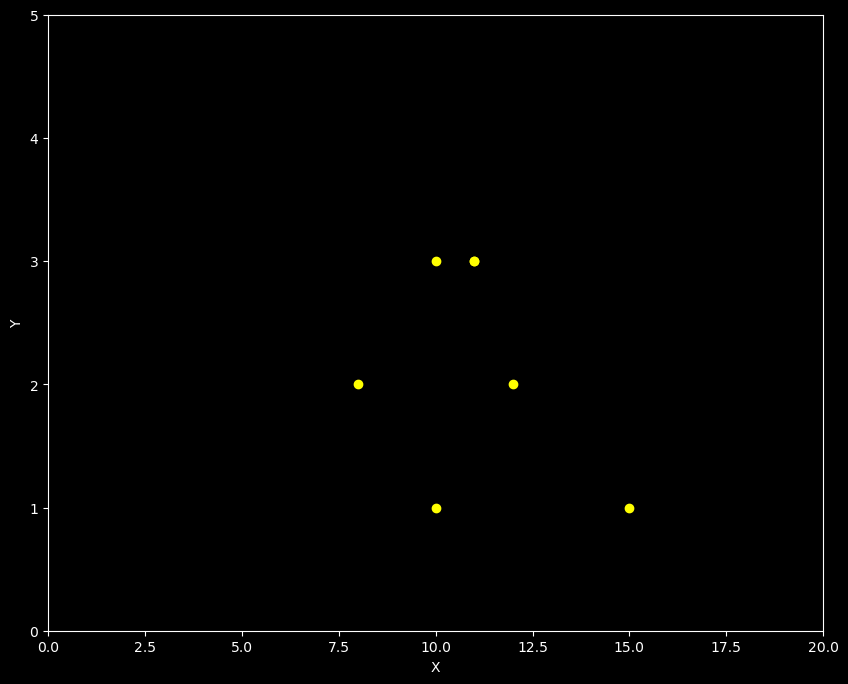

In [9]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['X'],D[:]['Y'],color='yellow')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0,20)
plt.ylim(0,5)
plt.show()

Knowing that the correlation is not close to -1 or 1, will our linear regression work perfectly where we can use $X$ to predict $Y$?
Lets find out how to fit the model and how its resulting performance is connected to the correlation we just calculated.

### (3.1) <u>Simple Linear Regression (single variable)</u>

#### $Y \approx \beta_0 + \beta_1X + \epsilon$ 

where $\beta_0$ is the offset of the line and $\beta_1$ is the slope.  When we say we are going to fit $X$ to $Y$ (or fit a model) we mean we will use the $X$ and $Y$ data in a supervised way to caluclate $\beta_0$ and $\beta_1$.  By finding these parameters we can draw a line onto new data where we only have the $X$ vector.  So how exactly do we figure out what values to use for $\beta_0$ and $\beta_1$? The intuition is that we are looking to fit our line so that it maximizes or balances out the predictive error over the long term. What we are really doing is trying to keep the total difference from the line we generate and the individual observation values from being minimal.  Lets take a look at a visual of this method. Here we are just taking the correlation value as the slope and then trying out an intercept that will cut through the plot.


In [10]:
#get the slop and intercept (equation of a line) from two co-lieanr points
def slope_intercept(p1,p2):
    m = (p2[1]-p1[1])/(p2[0]-p1[0])
    b = p1[1] - m*p1[0]
    return m,b
    
#lines can be drawn from any two points in the current dimensional space: IE they will be co-linear
p1 = (0,6)
p2 = (16,0)

m,b = slope_intercept(p1,p2)
m,b

(-0.375, 6.0)

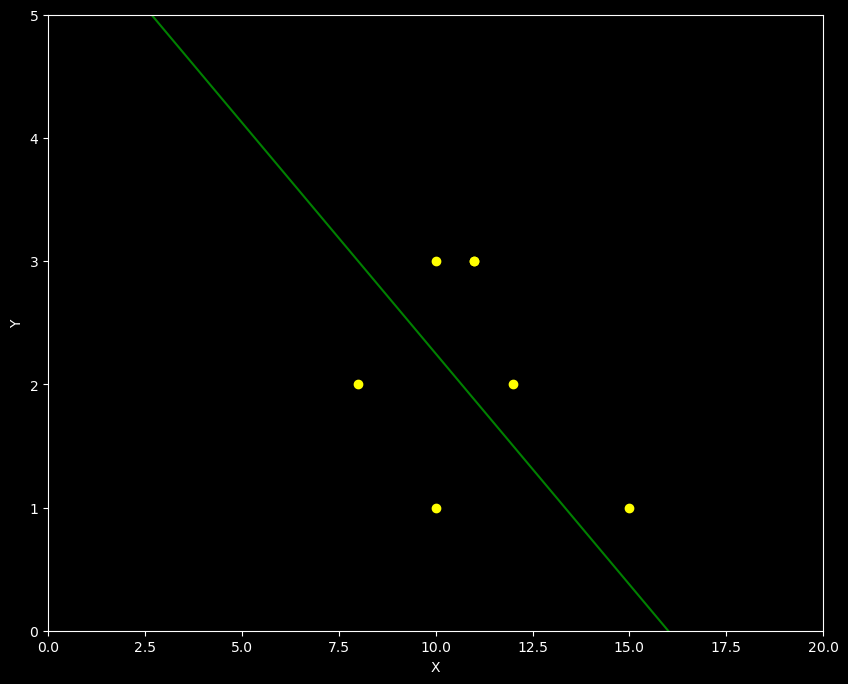

In [11]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['X'],D[:]['Y'],color='yellow')
plt.plot(p1[0:1]+p2[0:1],p1[1:]+p2[1:],color='green')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0,20)
plt.ylim(0,5)
plt.show()

Perfect, right? Not so fast! How far off are we with this manual fitting?  This important check we will formalize shortly so that we can automattically fit lines that perfrom very well in this regaurd. Lets make a new plot that shows the differences (residual error) between the actual $Y$ values and the predicted $\hat{Y}$ values which will be shown below in red.

In [12]:
lin_X = LinearRegression().fit(D[:][['X']],D[:][['Y']])
lin_Z = LinearRegression().fit(D[:][['Z']],D[:][['Y']])
lin_X

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
D.loc[:,'LX'] = lin_X.predict(D[:][['X']])
D.loc[:,'LZ'] = lin_Z.predict(D[:][['Z']])
D

,X,Y,Z,LX,LZ
0,10,1,4,2.285714,2.072464
1,8,2,6,2.571429,1.826087
2,11,3,2,2.142857,2.318841
3,15,1,2,1.571429,2.318841
4,11,3,4,2.142857,2.072464
5,10,3,1,2.285714,2.442029
6,12,2,5,2.000000,1.949275


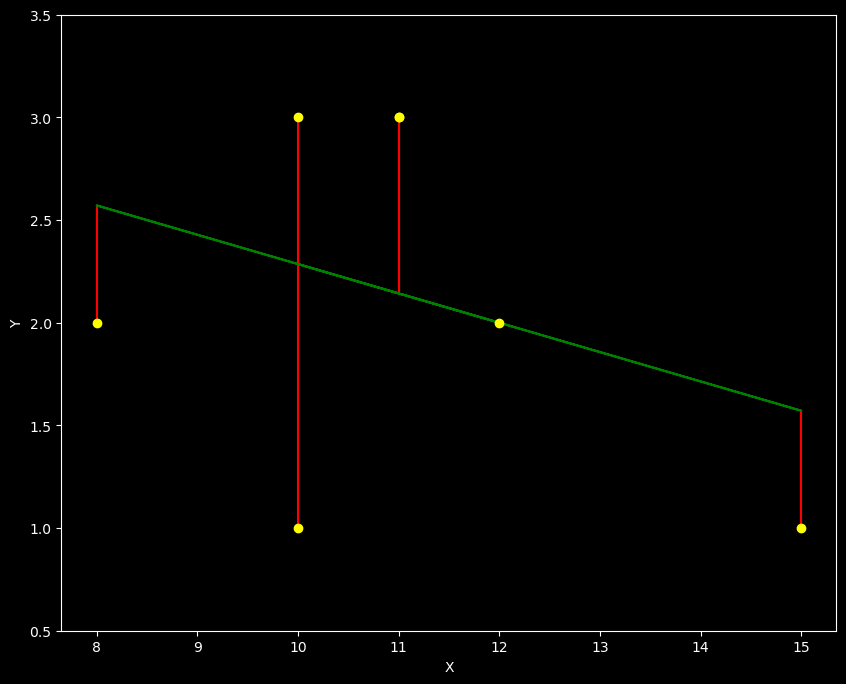

In [14]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['X'],D[:]['Y'],color='yellow',zorder=5)
plt.plot(D[:]['X'],D[:]['LX'],color='green',zorder=3)
plt.vlines(D[:]['X'],ymin=np.minimum(D[:]['Y'],D[:]['LX']),ymax=np.maximum(D[:]['Y'],D[:]['LX']),color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim(0.5,3.5)
plt.show()

How good is our manual fit compared to this linear regression in terms of being close to $Y$?

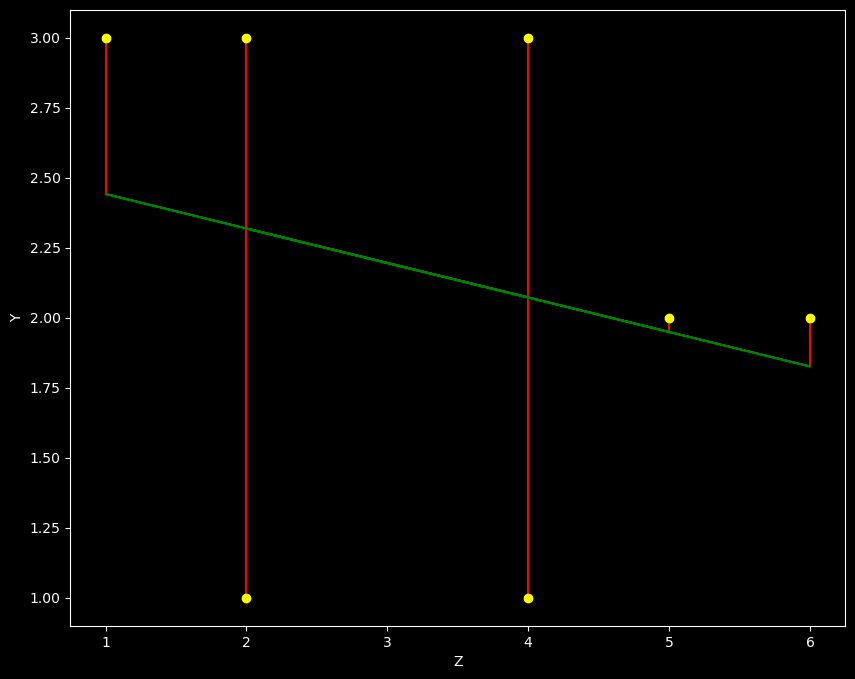

In [15]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['Z'],D[:]['Y'],color='yellow',zorder=5)
plt.plot(D[:]['Z'],D[:]['LZ'],color='green',zorder=3)
plt.vlines(D[:]['Z'],ymin=np.minimum(D[:]['Y'],D[:]['LZ']),ymax=np.maximum(D[:]['Y'],D[:]['LZ']),color='red')
plt.xlabel('Z')
plt.ylabel('Y')
plt.show()

Lets formulaize the concept of error and how to optimize it when automatically fitting a line to a set of points. We will start by using the classic Residual Sum of Squares (RSS):

#### $RSS = e_1^2+e_2^2+...+e_{n-1}^2+e_n^2$, 
where each error term is the square of the distance on the predictor's dimensional axis (the red lines in the plot above get squared).

<u>Question</u>: Why would we use the squared error instead of just the error itself?

For the $RSS$ error terms we expand each one as:  $e_i^2 = (y_i-\hat{\beta_0}-\hat{\beta_1}x_i)^2$ which gives us:

#### $RSS = (y_1-\hat{\beta_0}-\hat{\beta_1}x_1)^2 + (y_2-\hat{\beta_0}-\hat{\beta_1}x_2)^2 +
(y_{n-1}-\hat{\beta_0}-\hat{\beta_1}x_{n-1})^2 + (y_n-\hat{\beta_0}-\hat{\beta_1}x_n)^2$

which is then simplified using sigma notation and then minimized for our parameters $\hat{\beta_0}$ and $\hat{\beta_1}$:

#### $\hat{\beta_0} = \bar{y}-\hat{\beta_1}\bar{x}$
#### $\hat{\beta_1} = \displaystyle \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n}(x_i-\bar{x})^2}$

### (3.2) <u>Multiple Linear Regression</u>

If we can try to fit a line (1D geometric object) to a set of points (0D geometric objects) in 2D space, then it stands to reason that one may also attempt to fit a $(d-1)$ object (also known as a hyper-plane) to points in $d$-dimensional space.  These points are the rows of data in our dataframe that has $d$ columns where one variable is the one that we wish to predict with the $(d-1)$ others. We will see that fitting the hyper-planes has additional issues we need to consider since the assumptions that empower line fitting generally become convolted as we increase data dimension.

We will annotate the multiple variables as $X_1, X_2, ... , X_p$:

#### $Y \approx \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p + \epsilon$ 

#### $RSS = \displaystyle\sum_{i=1}^{n}(y_i-\hat{y_i})^2 = \sum_{i=1}^{n}(y_i-\hat{\beta_0}-\hat{\beta_1}x_{i1}- ... -\hat{\beta_p}x_{ip})^2$ (Residual Sum of Squares)

#### $TSS = \displaystyle\sum_{i=1}^{n}(y_i-\bar{y_i})^2$ (Total Sum of Squares)

We will consider the original matrix:

$D = \begin{pmatrix}
10 && 1 && 4 \\
8 && 2 && 6 \\
11 && 3 && 2 \\
15 && 1 && 2 \\
11 && 3 && 4 \\
10 && 3 && 1 \\
12 && 2 && 5 
\end{pmatrix} \Rightarrow \;\;\;\;
Y = D_1 =
\begin{pmatrix}
10 \\
8 \\
11 \\
15 \\
11 \\
10 \\
12 
\end{pmatrix},\;\;\;
X_1 = D_2 = 
\begin{pmatrix}
1 \\
2 \\
3 \\
1 \\
3 \\
3 \\
2  
\end{pmatrix},\;\;\;
X_2 = D_3 =
\begin{pmatrix}
4 \\
6 \\
2 \\
2 \\
4 \\
1 \\
5 
\end{pmatrix}
$


In [16]:
lin_XZ = LinearRegression().fit(D[:][['X','Z']],D[:][['Y']])
D.loc[:,'LXZ'] = lin_XZ.predict(D[:][['X','Z']])
D

,X,Y,Z,LX,LZ,LXZ
0,10,1,4,2.285714,2.072464,2.234513
1,8,2,6,2.571429,1.826087,2.213021
2,11,3,2,2.142857,2.318841,2.484197
3,15,1,2,1.571429,2.318841,1.571429
4,11,3,4,2.142857,2.072464,2.006321
5,10,3,1,2.285714,2.442029,2.951327
6,12,2,5,2.000000,1.949275,1.539191


In [17]:
def rss(y,p):
    return np.sum((y-p)**2)

def tss(y,p):
    return np.sum((y-np.mean(p))**2)

rss(D[:]['Y'],D[:]['LX']),tss(D[:]['Y'],D[:]['LX'])

(np.float64(4.285714285714286), np.float64(4.857142857142856))

In [18]:
#make a convex hull around the data X, Y
vs = np.asarray([[x,m] for x,m in zip(list(D[:]['X']),list(D[:]['Y']))])
hull =  ConvexHull(vs)
hull

#make a ploygon around the multiple-linear regression values
ks    = {x:[] for x in sorted(set(D[:]['X']))}
xs,ml = list(D[:]['X']),list(D[:]['LXZ'])
for i in range(len(xs)): ks[xs[i]] += [ml[i]]
ymax,ymin = [],[]
for k in ks:
    ymax += [[k,max(ks[k])]]
    ymin += [[k,min(ks[k])]]
ymax = np.asarray(ymax)
ymin = np.asarray(ymin)

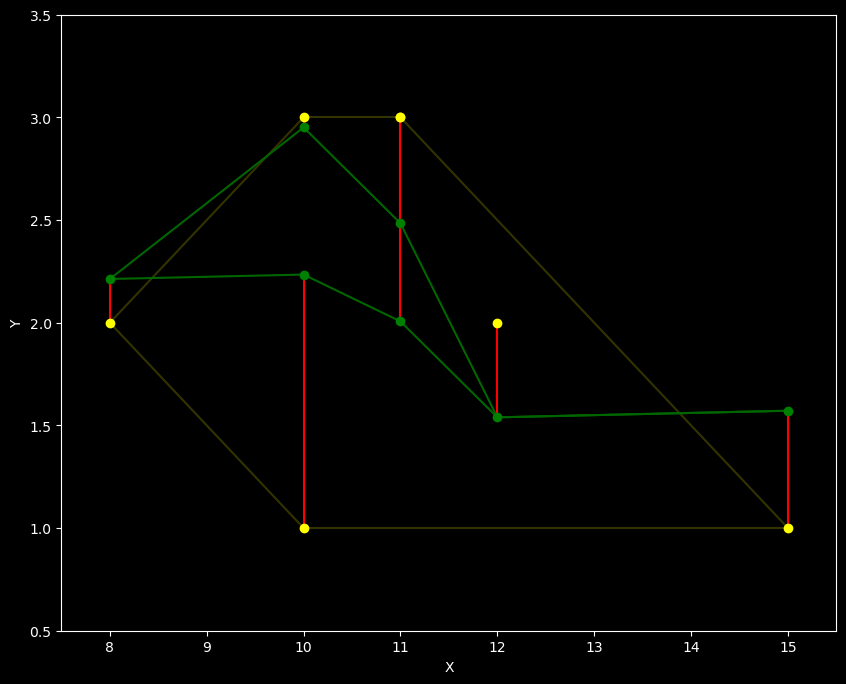

In [19]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['X'],D[:]['Y'],color='yellow',zorder=5)
for simplex in hull.simplices: plt.plot(vs[simplex,0],vs[simplex,1],color=(0.2,0.2,0))

plt.scatter(D[:]['X'],D[:]['LXZ'],color='green',zorder=3) #estimates of the ML model
plt.plot(ymax[:,0],ymax[:,1],color=(0,0.4,0))            #upper end of Y
plt.plot(ymin[:,0],ymin[:,1],color=(0,0.4,0))            #lower end of Y
    
plt.vlines(D[:]['X'],ymin=np.minimum(D[:]['Y'],D[:]['LXZ']),ymax=np.maximum(D[:]['Y'],D[:]['LXZ']),color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(7.5,15.5)
plt.ylim(0.5,3.5)
plt.show()

In [20]:
vs = np.asarray([[x,m] for x,m in zip(list(D[:]['Z']),list(D[:]['Y']))])
hull =  ConvexHull(vs)
hull

#make a ploygon around the multiple-linear regression values
ks    = {x:[] for x in sorted(set(D[:]['Z']))}
xs,ml = list(D[:]['Z']),list(D[:]['LXZ'])
for i in range(len(xs)): ks[xs[i]] += [ml[i]]
ymax,ymin = [],[]
for k in ks:
    ymax += [[k,max(ks[k])]]
    ymin += [[k,min(ks[k])]]
ymax = np.asarray(ymax)
ymin = np.asarray(ymin)

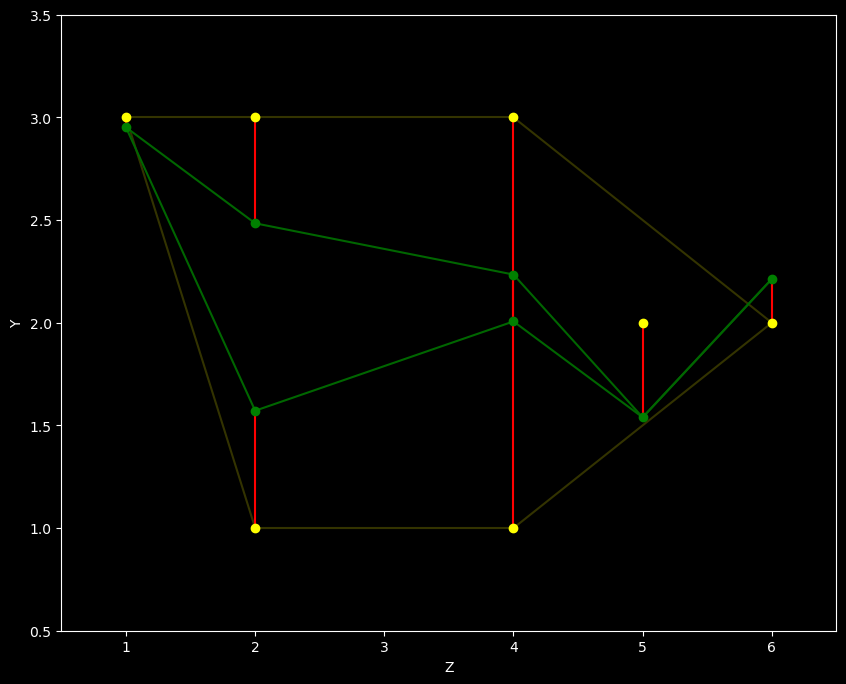

In [21]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(D[:]['Z'],D[:]['Y'],color='yellow',zorder=5)
for simplex in hull.simplices: plt.plot(vs[simplex,0],vs[simplex,1],color=(0.2,0.2,0))

plt.scatter(D[:]['Z'],D[:]['LXZ'],color='green',zorder=3) #estimates of the ML model
plt.plot(ymax[:,0],ymax[:,1],color=(0,0.4,0))            #upper end of Y
plt.plot(ymin[:,0],ymin[:,1],color=(0,0.4,0))            #lower end of Y
    
plt.vlines(D[:]['Z'],ymin=np.minimum(D[:]['Y'],D[:]['LXZ']),ymax=np.maximum(D[:]['Y'],D[:]['LXZ']),color='red')
plt.xlabel('Z')
plt.ylabel('Y')
plt.xlim(0.5,6.5)
plt.ylim(0.5,3.5)
plt.show()

#### (1) is at least one of the $X_j$ a useful predictor? (can the multi-lin model be used?)

We use a satistical test (hypothesis testing) to answer assuming $p<<n$:

#### $\;\;\;\; H_0: \beta_1 = \beta_2 = ... = \beta_p = 0$

#### $\;\;\;\; H_a: $ at least one $\beta_j$ is non-zero

We will use the F-statistic here (assuming F-shape):
#### $\;\;\;\; F = \frac{(TSS-RSS)/p}{(RSS)/(n-p-1)}$
#### $\;\;\;\; F=1 \Rightarrow H_0, \;\;\;\; F>1 \Rightarrow H_a$

Why does $p<n$ have to hold here to get a result?


In [22]:
D[:]['Y'].shape

(7,)

In [26]:
#building a model with statsmodels so that you get the statistics for free below (from the text)
sm_XZ = sm.OLS(D[:]['Y'],D[:][['X','Z']])
res = sm_XZ.fit()
res.summary()

/Users/teddytaussig/anaconda3/envs/COM328/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      Y   R-squared (uncentered):                   0.806
Model:                            OLS   Adj. R-squared (uncentered):              0.728
Method:                 Least Squares   F-statistic:                              10.36
Date:                Wed, 11 Feb 2026   Prob (F-statistic):                      0.0167
Time:                        09:04:18   Log-Likelihood:                         -10.029
No. Observations:                   7   AIC:                                      24.06
Df Residuals:                       5   BIC:                                      23.95
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.1608      0.077      2.087      0.091      -0.037       0.359
Z              0.0801      0.226      0.355      0.737      -0.500       0.660
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.510
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.634
Skew:                          -0.362   Prob(JB):                        0.728
Kurtosis:                       1.716   Cond. No.                         6.05
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
X = D[['X', 'Z']]
y = D['Y']

# create + fit model
lin_model = LinearRegression()
lin_model.fit(X, y)

lin_model.coef_,lin_model.intercept_,lin_model.score(D[:][['X','Z']],D[:]['Y']),lin_model.get_params() #get information from the model

(array([-0.22819216, -0.23893805]),
 np.float64(5.472187104930468),
 0.30739198334200923,
 {'copy_X': True,
  'fit_intercept': True,
  'n_jobs': None,
  'positive': False,
  'tol': 1e-06})

In [24]:
from ISLP import load_data
Auto = load_data('Auto')
Auto[0:10]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
ford galaxie 500,15.0,8,429.0,198,4341,10.0,70,1
chevrolet impala,14.0,8,454.0,220,4354,9.0,70,1
plymouth fury iii,14.0,8,440.0,215,4312,8.5,70,1
pontiac catalina,14.0,8,455.0,225,4425,10.0,70,1


In [25]:
#make some models now using the code above!



We could look at this a few ways, $F=10.36$ and the integration area of the F-distribution $>F=0.0167$ we could reject $H_0$ here. On the other hand 7 observations is not enough data to build a model on!

#### (2) is there a subset of variables that can be used instead of all of them?
#### in ML this is studies as the best subset X problem: (Best Subset Regression)

How many possible subsets are there for p variables?

$2^p$ is ... alot. Lets see how many variables will make this impractical:


In [26]:
2**2
2**4
2**8
2**16

65536

How many operations are needed to build each model?

This is an advanced topic since we have never discussed what is actually under the hood for lm.  At its core it is using [SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition) which has the dominant operation term from the matrix multiplication which as we discussed is a non-linear operator. The runtime complexity of each model is: $O(n^2p + p^3)$ which when combined by the number of model yeilds: $O((n^2p+p^3)2^p)$ Clearly the $p$ term is very bad when it grows...

#### Some solutions are:
(Forward Selection) start one at a time using the best single column vector

(Backward Selection) start at $p-1$ and keep removing the worst column vector

(Mixed Selection) alternate (2) and (1) remove the worste than find the best on the remaining (p-1), etc...

Selection(Random Selection) randomly select a subset and test to see if it scores higher based on a statisticp


#### (3) How well does the model Fit?

#### $RSE = \displaystyle\sqrt{\frac{1}{n-p-1}RSS}$

### (3.3) Qualitative Predictors and Interaction Terms

What do we do with our column vectors that only have a few values? How can we deal with variables $X_i$ and $X_j$ that are associated or connected (which means they will have some combination (synergy) effect)?

Dummy Variable
$
x_i =
  \begin{cases}
    1  & \quad \text{if the }i\text{th value is }=A\\
    0  & \quad \text{if the }i\text{th value is }=B
  \end{cases}
$

Which means the regression model will become (one-hot):

$
y_i = \beta_0 + \beta_1x_i + \epsilon_i =
  \begin{cases}
    \beta_0 + \beta_1+\epsilon  & \quad \text{if the }i\text{th value is }=A\\
    \beta_0 +\epsilon  & \quad \text{if the }i\text{th value is }=B
  \end{cases}
$

Or we could do:

$
x_i =
  \begin{cases}
    1  & \quad \text{if the }i\text{th value is }=A\\
    -1  & \quad \text{if the }i\text{th value is }=B
  \end{cases}
$

Which would become:

$
y_i = \beta_0 + \beta_1x_i + \epsilon_i =
  \begin{cases}
    \beta_0 + \beta_1+\epsilon  & \quad \text{if the }i\text{th value is }=A\\
    \beta_0 -\beta_1+\epsilon  & \quad \text{if the }i\text{th value is }=B
  \end{cases}
$


#### Interaction Terms
when we have some combination effects, we simply try to fit a model that can handle those interactions:

#### $Y \approx \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_1x_2$

### Regression Issues (some of the text items removed):

#### (0) Non-linearity of the response-predictor relationships (duh!!!)
Fitting a linear model assumes the linear relationship only...

#### (1) Correlation of error terms
When error is correlated it means duplicate or partial row duplication...

#### (2) Non-constant variance of error terms
Is the variance equal accross the variable value domain? If not LR will suck.  If you can try to find the distribution of the variance, you could make a transformation of $Y$ such as $log(Y), \sqrt(Y)$

#### (3) Collinearity
The issue of two vairables $X_i$ and $X_j$ have linear relationship (interaction terms can be used and dimensional reduction methods can be used here)